In [17]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# Single-Layer RNN Parameter

class RNNScratch(d2l.Module):
    def __init__(
        self,
        num_inputs: int,
        num_hiddens: int,
        sigma: float = 1e-2,
    ) -> None:
        super().__init__()
        
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        # W_xh: [D, H]
        self.W_xh = nn.Parameter(
            torch.randn(
                num_inputs,
                num_hiddens,
            ) * sigma
        )
        
        # W_hh: [H, H]        
        self.W_hh = nn.Parameter(
            torch.randn(
                num_hiddens,
                num_hiddens,
            ) * sigma
        )        
        
        # bias: [H]
        self.b_h = nn.Parameter(
            torch.zeros(num_hiddens)
        )

In [ ]:
# Single-Layer RNN Forward Computation

def rnn_scratch_forward(
    self: RNNScratch,
    
    # inputs: [T, B, D]
    inputs: torch.Tensor,
    
    # hidden state: [B, H]
    state: torch.Tensor | None = None,
) -> tuple[
    list[torch.Tensor],
    torch.Tensor,
]: 
    
    # if No Hidden State: [B, H]
    if state is None:
        state = torch.zeros(
            (
                inputs.shape[1],
                self.num_hiddens,
            ),
            device=inputs.device,
            dtype=inputs.dtype,
        )
        
    outputs: list[torch.Tensor] = []
    
    # inputs: [T, B, D]
    for X_t in inputs:
        
        # H_t = X_t @ W_xh + H_(t-1) @ W_hh + b_h
        state = torch.tanh(
            X_t @ self.W_xh
            + state @ self.W_hh
            + self.b_h
        )
        
        outputs.append(state)
        
        
    return outputs, state


setattr(
    RNNScratch,
    "forward",
    rnn_scratch_forward,
)

In [20]:
# Deep RNN Architecture

class StackedRNNScratch(d2l.Module):
    def __init__(
        self,
        num_inputs: int,
        num_hiddens: int,
        num_layers: int,
        sigma: float = 1e-2,
    ) -> None:
        super().__init__()
        
        if num_layers < 1:
            raise ValueError(
                "num_layers must be at least 1."
            )
        
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.sigma = sigma
        
        self.rnns = nn.Sequential(
            *[
                RNNScratch(
                    num_inputs=(
                        num_inputs
                        if layer_index == 0
                        else num_hiddens
                    ),
                    num_hiddens=num_hiddens,
                    sigma=sigma,
                )
                for layer_index in range(num_layers)
            ]
        )

In [21]:
# Deep RNN Forward Computation

def stacked_rnn_scratch_forward(
    self: StackedRNNScratch,
    inputs: torch.Tensor,
    states: list[torch.Tensor] | None = None,
) -> tuple[
    torch.Tensor,
    list[torch.Tensor]
]:
    
    if states is None:
        layer_states: list[torch.Tensor | None] = [
            None
            for _ in range(self.num_layers)
        ]
    else:
        if len(states) != self.num_layers:
            raise ValueError(
                "The number of states must match num_layers."
            )
            
        layer_states = list(states)
        
    
    final_states: list[torch.Tensor] = []
    outputs = inputs
    
    # nn.Sequential 순회 (in self.rnns)
    for layer_index, rnn_layer in enumerate(self.rnns):
        
        if not isinstance(
            rnn_layer,
            RNNScratch,
        ):
            raise TypeError(
                "Every layer must be an RNNScratch instance."
            )
            
        # forward to single rnn
        layer_outputs, final_state = rnn_layer(
            outputs,                  # 전체 Input Sequence    
            layer_states[layer_index] # 해당 Layer의 이전 Hidden State
        )
        
        # outputs: [T, B, H]
        outputs = torch.stack(
            layer_outputs,
            dim=0,
        )
        
        final_states.append(final_state)
        
    return outputs, final_states


setattr(
    StackedRNNScratch,
    "forward",
    stacked_rnn_scratch_forward,
)

In [ ]:
# Tensor Shape와 Parameter 검증

num_steps = 3
batch_size = 2
num_inputs = 4
num_hiddens = 8
num_layers = 2

# [T, B, D]
X = torch.randn(
    num_steps,
    batch_size,
    num_inputs,
)

rnn_block = StackedRNNScratch(
    num_inputs=num_inputs,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
)

# 1) outputs: [T, B, H]
#  마지막 Layer가 모든 Time Step에서 만든 Output
# 2) final_states: [L, B, H]
#  각 Layer가 마지막 Time step에서 만든 State
Y, final_states = rnn_block(X)

num_parameters = sum(
    parameter.numel()
    for parameter in rnn_block.parameters()
)

print("Input shape:", tuple(X.shape))
print("Output shape:", tuple(Y.shape))
print(
    "Final state shapes:",
    [
        tuple(state.shape)
        for state in final_states
    ],
)
print("Parameter count:", num_parameters)

Input shape: (3, 2, 4)
Output shape: (3, 2, 8)
Final state shapes: [(2, 8), (2, 8)]
Parameter count: 240


In [23]:
# Time Machine Deep RNN 구성

data = d2l.TimeMachine(
    batch_size=1024,
    num_steps=32,
)

rnn_block = StackedRNNScratch(
    num_inputs=len(data.vocab),
    num_hiddens=32,
    num_layers=2,
)

model = d2l.RNNLMScratch(
    rnn_block,
    vocab_size=len(data.vocab),
    lr=2,
)

print("Vocabulary size:", len(data.vocab))
print("Number of RNN layers:", rnn_block.num_layers)
print("Hidden size:", rnn_block.num_hiddens)

Vocabulary size: 28
Number of RNN layers: 2
Hidden size: 32


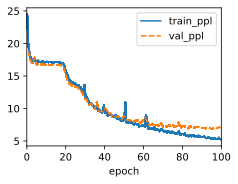

In [24]:
# Device Checking & Training

num_gpus = int(
    torch.cuda.is_available()
)

device = torch.device(
    "cuda"
    if num_gpus == 1
    else "cpu"
)

print("Training device:", device)

if num_gpus == 1:
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

trainer = d2l.Trainer(
    max_epochs=100,
    gradient_clip_val=1,
    num_gpus=num_gpus,
)

trainer.fit(
    model,
    data,
)